# Honey Yield Prediction

## DuckDB Practice and Feature Engineering

Author: Stephanie Nord

# 1. Project Setup

This section establishes the project environment by connecting to the DuckDB database, defining reusable project paths, and locating the source data. Organizing these tasks at the beginning of the notebook makes the workflow portable and easier to reproduce.

## Connect to DuckDB

```
Zenodo ZIP
      │
      ▼
Extract Daily Measurement Files
      │
      ▼
DuckDB (honey_daily)
      │
      ▼
Data Quality Assessment
      │
      ▼
Transformation
      │
      ▼
Feature Engineering
      │
      ▼
Modeling Dataset
      │
      ▼
Predictive Model
```

In [15]:
import duckdb
import pandas as pd
from pathlib import Path
import zipfile

In [16]:
# Connect to DuckDB
con = duckdb.connect("honey.duckdb")

In [17]:
# Define project paths
working_dir = Path.cwd()
project_root = working_dir.parent

print(f"Working Directory: {working_dir}")
print(f"Project Root: {project_root}")

Working Directory: c:\Users\Joshua\Documents\honey-yield-predictive-model\Stephanie_Work
Project Root: c:\Users\Joshua\Documents\honey-yield-predictive-model


In [18]:
list(project_root.iterdir())

[WindowsPath('c:/Users/Joshua/Documents/honey-yield-predictive-model/.env'),
 WindowsPath('c:/Users/Joshua/Documents/honey-yield-predictive-model/.git'),
 WindowsPath('c:/Users/Joshua/Documents/honey-yield-predictive-model/.gitignore'),
 WindowsPath('c:/Users/Joshua/Documents/honey-yield-predictive-model/Beehive_Honey_Yield_Project.ipynb'),
 WindowsPath('c:/Users/Joshua/Documents/honey-yield-predictive-model/data-guide.md'),
 WindowsPath('c:/Users/Joshua/Documents/honey-yield-predictive-model/David_Work'),
 WindowsPath('c:/Users/Joshua/Documents/honey-yield-predictive-model/honey-yield-predictive-model'),
 WindowsPath('c:/Users/Joshua/Documents/honey-yield-predictive-model/Joshua_Work'),
 WindowsPath('c:/Users/Joshua/Documents/honey-yield-predictive-model/README.md'),
 WindowsPath('c:/Users/Joshua/Documents/honey-yield-predictive-model/Stephanie_Work'),
 WindowsPath('c:/Users/Joshua/Documents/honey-yield-predictive-model/the-beehive')]

# 2. Extract Data

This section locates the publication archive, inspects its contents, and extracts the daily measurement files used throughout the remainder of the project.

```text
Zenodo Publication Archive (.zip)
        │
        ▼
Inspect Archive
        │
        ▼
Identify Daily Measurement Files
        │
        ▼
Extract Daily Measurement Files

### 2.1 Inspect archive contents

In [19]:
# Locate ZIP files in Downloads
downloads = Path.home() / "Downloads"

zip_files = list(downloads.glob("*.zip"))
zip_files

[WindowsPath('C:/Users/Joshua/Downloads/archive (1).zip'),
 WindowsPath('C:/Users/Joshua/Downloads/archive (2).zip'),
 WindowsPath('C:/Users/Joshua/Downloads/archive.zip'),
 WindowsPath('C:/Users/Joshua/Downloads/Weeks3&4Exercise.zip')]

In [20]:
# Select the Zenodo publication dataset ZIP
zip_path = downloads / "bob_publication_data.zip"

zip_path.exists(), zip_path

(False, WindowsPath('C:/Users/Joshua/Downloads/bob_publication_data.zip'))

In [21]:
# Inspect ZIP contents without extracting
with zipfile.ZipFile(zip_path) as z:
    files = z.namelist()

len(files)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Joshua\\Downloads\\bob_publication_data.zip'

In [ ]:
# Preview first 50 files in the archive
files[:50]

['bob_publication_data/',
 'bob_publication_data/readme.txt',
 'bob_publication_data/years/',
 'bob_publication_data/years/2019/',
 'bob_publication_data/years/2019/preprocessed/',
 'bob_publication_data/years/2019/preprocessed/2019_d/',
 'bob_publication_data/years/2019/preprocessed/2019_d/11.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/22.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/25.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/26.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/27.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/43.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/46.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/48.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/49.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/5.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/56.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/58.csv',
 'bob_p

> **Design Decision**
>
> The publication archive contains multiple data products, including event files and multiple temporal resolutions. Only the daily measurement files are extracted because they provide an appropriate starting point for exploratory analysis and predictive modeling.

### 2.2 Count daily, hourly, and minute files

In [ ]:
import re

daily_files = [
    f for f in files
    if re.search(r"/\d{4}_d/[^/]+\.csv$", f)
]

hourly_files = [
    f for f in files
    if re.search(r"/\d{4}_h/[^/]+\.csv$", f)
]

minute_files = [
    f for f in files
    if re.search(r"/\d{4}_m/[^/]+\.csv$", f)
]

print(f"Daily files:  {len(daily_files)}")
print(f"Hourly files: {len(hourly_files)}")
print(f"Minute files: {len(minute_files)}")

Daily files:  151
Hourly files: 151
Minute files: 429


### 2.3 Identify true daily measurement files

In [ ]:
daily_measurement_files = [
    f for f in files
    if re.search(r"/\d{4}_d/[^/]+\.csv$", f)
    and "/years/" in f
    and "/events/" not in f
]

print(f"True daily measurement files: {len(daily_measurement_files)}")
daily_measurement_files[:10]

True daily measurement files: 151


['bob_publication_data/years/2019/preprocessed/2019_d/11.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/22.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/25.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/26.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/27.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/43.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/46.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/48.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/49.csv',
 'bob_publication_data/years/2019/preprocessed/2019_d/5.csv']

### 2.4 Extract true daily files into Daily_Only

In [ ]:
daily_only_folder = project_root / "Data" / "Daily_Only"
daily_only_folder.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path) as z:
    for file in daily_measurement_files:
        z.extract(file, path=daily_only_folder)

print("Extracted true daily measurement files.")

Extracted true daily measurement files.


### 2.5 Verify extracted file count

In [ ]:
daily_only_csvs = list(daily_only_folder.rglob("*.csv"))

print(f"Extracted true daily CSV files: {len(daily_only_csvs)}")
daily_only_csvs[:5]

Extracted true daily CSV files: 453


[WindowsPath('C:/Users/sfnor/Miniconda3/envs/pandas_book/honey-yield-predictive-model/Data/Daily_Only/bob_publication_data/years/2019/preprocessed/2019_d/11.csv'),
 WindowsPath('C:/Users/sfnor/Miniconda3/envs/pandas_book/honey-yield-predictive-model/Data/Daily_Only/bob_publication_data/years/2019/preprocessed/2019_d/22.csv'),
 WindowsPath('C:/Users/sfnor/Miniconda3/envs/pandas_book/honey-yield-predictive-model/Data/Daily_Only/bob_publication_data/years/2019/preprocessed/2019_d/25.csv'),
 WindowsPath('C:/Users/sfnor/Miniconda3/envs/pandas_book/honey-yield-predictive-model/Data/Daily_Only/bob_publication_data/years/2019/preprocessed/2019_d/26.csv'),
 WindowsPath('C:/Users/sfnor/Miniconda3/envs/pandas_book/honey-yield-predictive-model/Data/Daily_Only/bob_publication_data/years/2019/preprocessed/2019_d/27.csv')]

In [ ]:
measurement_files = [
    f for f in files
    if "years" in f
    and "preprocessed" in f
    and "_d" in f
    and "events" not in f
    and f.endswith(".csv")
]

len(measurement_files), measurement_files[:20]

(453,
 ['bob_publication_data/years/2019/preprocessed/2019_d/11.csv',
  'bob_publication_data/years/2019/preprocessed/2019_d/22.csv',
  'bob_publication_data/years/2019/preprocessed/2019_d/25.csv',
  'bob_publication_data/years/2019/preprocessed/2019_d/26.csv',
  'bob_publication_data/years/2019/preprocessed/2019_d/27.csv',
  'bob_publication_data/years/2019/preprocessed/2019_d/43.csv',
  'bob_publication_data/years/2019/preprocessed/2019_d/46.csv',
  'bob_publication_data/years/2019/preprocessed/2019_d/48.csv',
  'bob_publication_data/years/2019/preprocessed/2019_d/49.csv',
  'bob_publication_data/years/2019/preprocessed/2019_d/5.csv',
  'bob_publication_data/years/2019/preprocessed/2019_d/56.csv',
  'bob_publication_data/years/2019/preprocessed/2019_d/58.csv',
  'bob_publication_data/years/2019/preprocessed/2019_d/6.csv',
  'bob_publication_data/years/2019/preprocessed/2019_d/62.csv',
  'bob_publication_data/years/2019/preprocessed/2019_h/11.csv',
  'bob_publication_data/years/2019/p

# 3. Anchor Table

> **Anchor Table**
>
> The `honey_daily` table is treated as the raw DuckDB anchor table. It preserves the imported daily measurement files with minimal changes. Downstream cleaning, type conversion, feature engineering, and modeling steps should build from this table rather than modifying it directly.

In [ ]:
con.execute("""
SHOW TABLES;
""").df()

,name
0,honey_daily
1,honey_daily_clean
2,honey_daily_summary
3,honey_features
4,honey_model
5,honey_model_candidates


In [ ]:
daily_measurement_folder = project_root / "Data" / "Daily_Only"
csv_pattern = str(daily_measurement_folder / "**" / "*.csv")

daily_measurement_csvs = list(daily_measurement_folder.rglob("*.csv"))

print(f"Daily measurement folder: {daily_measurement_folder}")
print(f"Daily measurement CSV files: {len(daily_measurement_csvs)}")
print(csv_pattern)

Daily measurement folder: C:\Users\sfnor\Miniconda3\envs\pandas_book\honey-yield-predictive-model\Data\Daily_Only
Daily measurement CSV files: 453
C:\Users\sfnor\Miniconda3\envs\pandas_book\honey-yield-predictive-model\Data\Daily_Only\**\*.csv


In [ ]:
# Check whether the raw anchor table already exists
existing_tables = con.execute("SHOW TABLES;").df()

if "honey_daily" in existing_tables["name"].values:
    print("Using existing anchor table: honey_daily")
else:
    print("Creating anchor table: honey_daily")

    con.execute(f"""
    CREATE TABLE honey_daily AS
    SELECT *
    FROM read_csv_auto(
        '{csv_pattern}',
        filename = true,
        union_by_name = true,
        all_varchar = true
    );
    """)

    print("Created anchor table: honey_daily")

Using existing anchor table: honey_daily


In [ ]:
# Extract only daily measurement CSVs
with zipfile.ZipFile(zip_path) as z:
    for file in measurement_files:
        z.extract(file, path=daily_measurement_folder)

print(f"Extracted {len(measurement_files)} daily measurement CSV files.")

Extracted 453 daily measurement CSV files.


In [ ]:
daily_measurement_csvs = list(daily_measurement_folder.rglob("*.csv"))

len(daily_measurement_csvs), daily_measurement_csvs[:5]

(453,
 [WindowsPath('C:/Users/sfnor/Miniconda3/envs/pandas_book/honey-yield-predictive-model/Data/Daily_Only/bob_publication_data/years/2019/preprocessed/2019_d/11.csv'),
  WindowsPath('C:/Users/sfnor/Miniconda3/envs/pandas_book/honey-yield-predictive-model/Data/Daily_Only/bob_publication_data/years/2019/preprocessed/2019_d/22.csv'),
  WindowsPath('C:/Users/sfnor/Miniconda3/envs/pandas_book/honey-yield-predictive-model/Data/Daily_Only/bob_publication_data/years/2019/preprocessed/2019_d/25.csv'),
  WindowsPath('C:/Users/sfnor/Miniconda3/envs/pandas_book/honey-yield-predictive-model/Data/Daily_Only/bob_publication_data/years/2019/preprocessed/2019_d/26.csv'),
  WindowsPath('C:/Users/sfnor/Miniconda3/envs/pandas_book/honey-yield-predictive-model/Data/Daily_Only/bob_publication_data/years/2019/preprocessed/2019_d/27.csv')])

> **Why load all columns as `VARCHAR`?**
>
> The daily measurement files contain schema differences and inconsistent data types. Loading all columns as text prevents import failures caused by mixed numeric, Boolean, and missing values. Data types will be validated and converted during the transformation stage after all files have been successfully loaded into DuckDB.

In [ ]:
con.execute("""
SHOW TABLES;
""").df()

,name
0,honey_daily
1,honey_daily_clean
2,honey_daily_summary
3,honey_features
4,honey_model
5,honey_model_candidates


In [ ]:
con.execute("""
SELECT COUNT(*) AS row_count
FROM honey_daily;
""").df()

,row_count
0,29172


In [ ]:
con.execute("""
SELECT *
FROM honey_daily
LIMIT 10;
""").df()

,column00,X.1,time,X,t_i_1,t_i_2,t_i_3,t_i_4,t_i_5,t_o,...,died.next,died.last.dif,died.next.dif,swarming.last,swarming.next,swarming.last.dif,swarming.next.dif,lon,lat,filename
0,1,1,2019-06-24,251869,30.1617157794677,30.385575095057,26.3360266159696,26.0898288973384,NA,20.4259743346008,...,NA,NA,NA,NA,NA,NA,339.55,8.8,53.1,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
1,2,2,2019-06-25,252720.5,31.2451388888889,32.2414930555556,29.9884114583333,29.8963541666667,NA,25.7718967013889,...,NA,NA,NA,NA,NA,NA,338.958680555556,8.8,53.1,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
2,3,3,2019-06-26,254160.5,30.2679036458333,30.3205295138889,27.1550998263889,26.8098958333333,NA,21.6816840277778,...,NA,NA,NA,NA,NA,NA,337.958680555556,8.8,53.1,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
3,4,4,2019-06-27,255550.437213566,26.2060895967003,25.5157252520623,18.6211617781852,18.2064906049496,NA,13.6424725022915,...,NA,NA,NA,NA,NA,NA,336.993446379468,8.8,53.1,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
4,5,5,2019-06-28,256601,26.8146167557932,26.2207553475936,15.9831773618538,18.8590129233512,NA,13.7718917112299,...,NA,NA,NA,NA,NA,NA,336.263888888889,8.8,53.1,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
5,6,6,2019-07-02,262850,28.2874087591241,28.0590784671533,24.6019616788321,24.1439324817518,NA,19.0971715328467,...,NA,NA,NA,NA,NA,NA,331.924305555556,8.8,53.1,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
6,7,7,2019-07-17,284713.114391144,25.7999153325123,25.1900015394089,22.6236530172414,22.3527555418719,NA,18.4852601600985,...,NA,NA,NA,NA,NA,NA,316.741587228372,8.8,53.1,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
7,8,8,2019-07-18,285840.5,25.4922960069444,24.67265625,22.0047092013889,21.7590494791667,NA,19.3501953125,...,NA,NA,NA,NA,NA,NA,315.958680555556,8.8,53.1,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
8,9,9,2019-07-19,287280.5,26.7734592013889,26.2806423611111,23.8123480902778,23.5030381944444,NA,20.2501085069444,...,NA,NA,NA,NA,NA,NA,314.958680555556,8.8,53.1,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
9,10,10,2019-07-20,288720.5,25.0897786458333,24.2613498263889,21.5822482638889,21.3791883680556,NA,18.82421875,...,NA,NA,NA,NA,NA,NA,313.958680555556,8.8,53.1,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...


In [ ]:
con.execute("""
DESCRIBE honey_daily;
""").df()

,column_name,column_type,null,key,default,extra
0,column00,VARCHAR,YES,None,None,None
1,X.1,VARCHAR,YES,None,None,None
2,time,VARCHAR,YES,None,None,None
3,X,VARCHAR,YES,None,None,None
4,t_i_1,VARCHAR,YES,None,None,None
5,t_i_2,VARCHAR,YES,None,None,None
6,t_i_3,VARCHAR,YES,None,None,None
7,t_i_4,VARCHAR,YES,None,None,None
8,t_i_5,VARCHAR,YES,None,None,None
9,t_o,VARCHAR,YES,None,None,None


# 4. Explore the Raw Data

In [ ]:
con.execute("""
SELECT COUNT(*) AS row_count
FROM honey_daily;
""").df()

,row_count
0,29172


In [ ]:
con.execute("""
SELECT COUNT(DISTINCT filename) AS source_file_count
FROM honey_daily;
""").df()

,source_file_count
0,151


In [ ]:
con.execute("""
SELECT
    MIN(time) AS min_time,
    MAX(time) AS max_time
FROM honey_daily;
""").df()

,min_time,max_time
0,2019-06-24,2022-12-31


In [ ]:
con.execute("""
SELECT
    year,
    COUNT(*) AS row_count
FROM honey_daily
GROUP BY year
ORDER BY year;
""").df()

,year,row_count
0,2019,1112
1,2020,9347
2,2021,9554
3,2022,9159


```2019 contains substantially fewer records because data collection began during the year. The remaining years contain approximately 11–12 million observations each, providing relatively balanced longitudinal coverage.```

In [ ]:
con.execute("""
SELECT
    filename,
    COUNT(*) AS row_count
FROM honey_daily
GROUP BY filename
ORDER BY row_count DESC
LIMIT 10;
""").df()

,filename,row_count
0,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,349
1,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,349
2,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,348
3,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,347
4,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,346
5,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,343
6,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,343
7,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,343
8,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,343
9,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,342


In [ ]:
con.execute("""
SELECT
    COUNT(*) AS total_rows,

    SUM(CASE WHEN time IS NULL THEN 1 ELSE 0 END) AS time_nulls,
    SUM(CASE WHEN weight_kg IS NULL THEN 1 ELSE 0 END) AS weight_nulls,
    SUM(CASE WHEN t_i_1 IS NULL THEN 1 ELSE 0 END) AS internal_temp1_nulls,
    SUM(CASE WHEN t_o IS NULL THEN 1 ELSE 0 END) AS outside_temp_nulls,
    SUM(CASE WHEN h IS NULL THEN 1 ELSE 0 END) AS humidity_nulls,
    SUM(CASE WHEN p IS NULL THEN 1 ELSE 0 END) AS pressure_nulls,
    SUM(CASE WHEN lon IS NULL THEN 1 ELSE 0 END) AS longitude_nulls,
    SUM(CASE WHEN lat IS NULL THEN 1 ELSE 0 END) AS latitude_nulls

FROM honey_daily;
""").df()

,total_rows,time_nulls,weight_nulls,internal_temp1_nulls,outside_temp_nulls,humidity_nulls,pressure_nulls,longitude_nulls,latitude_nulls
0,29172,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 5. Data Quality Assessment

In [ ]:
con.execute("""
SELECT
    COUNT(*) AS total_rows,

    SUM(CASE WHEN weight_kg IS NULL THEN 1 ELSE 0 END) AS weight_nulls,
    SUM(CASE WHEN weight_kg = 'NA' THEN 1 ELSE 0 END) AS weight_na,
    SUM(CASE WHEN weight_kg = '' THEN 1 ELSE 0 END) AS weight_blank

FROM honey_daily;
""").df()

,total_rows,weight_nulls,weight_na,weight_blank
0,29172,0.0,17.0,0.0


>Observation
>
>The dataset does not use SQL NULL values for missing observations. Instead, missing measurements are represented by the string "NA". During the transformation stage, these values will be converted to proper SQL NULLs before numeric type conversion.

In [ ]:
con.execute("""
SELECT
    SUM(CASE WHEN weight_kg = 'NA' THEN 1 ELSE 0 END) AS weight_na,
    SUM(CASE WHEN t_i_1 = 'NA' THEN 1 ELSE 0 END) AS internal_temp_na,
    SUM(CASE WHEN t_o = 'NA' THEN 1 ELSE 0 END) AS outside_temp_na,
    SUM(CASE WHEN h = 'NA' THEN 1 ELSE 0 END) AS humidity_na,
    SUM(CASE WHEN p = 'NA' THEN 1 ELSE 0 END) AS pressure_na,
    SUM(CASE WHEN lon = 'NA' THEN 1 ELSE 0 END) AS longitude_na,
    SUM(CASE WHEN lat = 'NA' THEN 1 ELSE 0 END) AS latitude_na
FROM honey_daily;
""").df()

,weight_na,internal_temp_na,outside_temp_na,humidity_na,pressure_na,longitude_na,latitude_na
0,17.0,7430.0,6782.0,10091.0,8810.0,0.0,0.0


# 6. Transform the Data


```text
Raw DuckDB Anchor
        │
        ▼
Clean Modeling Table

## 6.1 Normalize Missing Values

>The raw anchor table stores missing observations as the string "NA" rather than SQL NULL. This step converts those placeholder values into proper NULL values so DuckDB can correctly handle missing data during numeric conversion and analysis.

## 6.2 Convert Data Types

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE honey_daily_clean AS
SELECT
    TRY_CAST(time AS TIMESTAMP) AS time,

    TRY_CAST(NULLIF(weight_kg, 'NA') AS DOUBLE) AS weight_kg,
    TRY_CAST(NULLIF(weight_delta, 'NA') AS DOUBLE) AS weight_delta,

    TRY_CAST(NULLIF(t_i_1, 'NA') AS DOUBLE) AS temp_internal_1,
    TRY_CAST(NULLIF(t_i_2, 'NA') AS DOUBLE) AS temp_internal_2,
    TRY_CAST(NULLIF(t_i_3, 'NA') AS DOUBLE) AS temp_internal_3,
    TRY_CAST(NULLIF(t_i_4, 'NA') AS DOUBLE) AS temp_internal_4,
    TRY_CAST(NULLIF(t_o, 'NA') AS DOUBLE) AS temp_outside,

    TRY_CAST(NULLIF(h, 'NA') AS DOUBLE) AS humidity,
    TRY_CAST(NULLIF(p, 'NA') AS DOUBLE) AS pressure,

    TRY_CAST(NULLIF(lat, 'NA') AS DOUBLE) AS latitude,
    TRY_CAST(NULLIF(lon, 'NA') AS DOUBLE) AS longitude,

    filename

FROM honey_daily;
""")

In [ ]:
con.execute("""
SELECT *
FROM honey_daily_clean
LIMIT 10;
""").df()

,time,weight_kg,weight_delta,temp_internal_1,temp_internal_2,temp_internal_3,temp_internal_4,temp_outside,humidity,pressure,latitude,longitude,filename
0,2019-06-24,21.822797,0.000039,30.161716,30.385575,26.336027,26.089829,20.425974,47.176078,1021.723958,53.1,8.8,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
1,2019-06-25,21.985121,0.000268,31.245139,32.241493,29.988411,29.896354,25.771897,47.086050,1019.853452,53.1,8.8,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
2,2019-06-26,22.321525,0.000111,30.267904,30.320530,27.155100,26.809896,21.681684,58.324521,1024.251167,53.1,8.8,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
3,2019-06-27,22.568542,0.000003,26.206090,25.515725,18.621162,18.206491,13.642473,64.346166,1028.993680,53.1,8.8,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
4,2019-06-28,22.909544,-0.000060,26.814617,26.220755,15.983177,18.859013,13.771892,65.556073,1028.121594,53.1,8.8,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
5,2019-07-02,22.401969,-0.000407,28.287409,28.059078,24.601962,24.143932,19.097172,40.400475,1023.606215,53.1,8.8,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
6,2019-07-17,21.149280,-0.000283,25.799915,25.190002,22.623653,22.352756,18.485260,50.089126,1016.004314,53.1,8.8,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
7,2019-07-18,21.099951,-0.000075,25.492296,24.672656,22.004709,21.759049,19.350195,52.539008,1012.753447,53.1,8.8,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
8,2019-07-19,20.992623,-0.000061,26.773459,26.280642,23.812348,23.503038,20.250109,50.772906,1014.214056,53.1,8.8,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...
9,2019-07-20,21.186723,0.000440,25.089779,24.261350,21.582248,21.379188,18.824219,59.539981,1012.881404,53.1,8.8,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...


In [ ]:
con.execute("""
DESCRIBE honey_daily_clean;
""").df()

,column_name,column_type,null,key,default,extra
0,time,TIMESTAMP,YES,None,None,None
1,weight_kg,DOUBLE,YES,None,None,None
2,weight_delta,DOUBLE,YES,None,None,None
3,temp_internal_1,DOUBLE,YES,None,None,None
4,temp_internal_2,DOUBLE,YES,None,None,None
5,temp_internal_3,DOUBLE,YES,None,None,None
6,temp_internal_4,DOUBLE,YES,None,None,None
7,temp_outside,DOUBLE,YES,None,None,None
8,humidity,DOUBLE,YES,None,None,None
9,pressure,DOUBLE,YES,None,None,None


## 6.3 Verify Transformed Data

## 7. Feature Engineering

This section converts cleaned sensor measurements into variables that capture hive history and temporal patterns. Before engineering lag and rolling features, the observation frequency and hive identifier must be established to ensure that calculations are performed within each hive and at the correct time scale.











### 7.1 Validate Observation Frequency

In [ ]:
con.execute("""
WITH sample_file AS (
    SELECT filename
    FROM honey_daily_clean
    LIMIT 1
),
ordered_measurements AS (
    SELECT
        filename,
        time,
        LAG(time) OVER (
            PARTITION BY filename
            ORDER BY time
        ) AS previous_time
    FROM honey_daily_clean
    WHERE filename = (SELECT filename FROM sample_file)
)
SELECT
    filename,
    previous_time,
    time,
    DATE_DIFF('minute', previous_time, time) AS minutes_between_readings
FROM ordered_measurements
WHERE previous_time IS NOT NULL
LIMIT 20;
""").df()

,filename,previous_time,time,minutes_between_readings
0,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-06-24,2019-06-25,1440
1,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-06-25,2019-06-26,1440
2,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-06-26,2019-06-27,1440
3,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-06-27,2019-06-28,1440
4,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-06-28,2019-07-02,5760
5,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-07-02,2019-07-17,21600
6,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-07-17,2019-07-18,1440
7,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-07-18,2019-07-19,1440
8,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-07-19,2019-07-20,1440
9,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-07-20,2019-07-21,1440


In [ ]:
con.execute("""
WITH sample_file AS (
    SELECT filename
    FROM honey_daily_clean
    LIMIT 1
)
SELECT
    CAST(time AS DATE) AS measurement_date,
    COUNT(*) AS readings_per_day
FROM honey_daily_clean
WHERE filename = (SELECT filename FROM sample_file)
GROUP BY measurement_date
ORDER BY measurement_date
LIMIT 20;
""").df()

,measurement_date,readings_per_day
0,2019-06-24,1
1,2019-06-25,1
2,2019-06-26,1
3,2019-06-27,1
4,2019-06-28,1
5,2019-07-02,1
6,2019-07-17,1
7,2019-07-18,1
8,2019-07-19,1
9,2019-07-20,1


### 7.2 Create Historical Features

In [ ]:
# Create the feature table only if it does not already exist
existing_tables = con.execute("SHOW TABLES;").df()

if "honey_features" in existing_tables["name"].values:
    print("Using existing feature table: honey_features")
else:
    print("Creating feature table: honey_features")

    con.execute("""
    CREATE TABLE honey_features AS
    SELECT
        *,

        LAG(weight_kg) OVER (
            PARTITION BY filename
            ORDER BY time
        ) AS previous_observed_weight_kg,

        weight_kg
        - LAG(weight_kg) OVER (
            PARTITION BY filename
            ORDER BY time
        ) AS observed_weight_change_kg,

        DATE_DIFF(
            'day',
            LAG(time) OVER (
                PARTITION BY filename
                ORDER BY time
            ),
            time
        ) AS days_since_previous_observation

    FROM honey_daily_clean;
    """)

    print("Created feature table: honey_features")

Using existing feature table: honey_features


In [ ]:
con.execute("""
SELECT
    filename,
    time,
    weight_kg,
    previous_observed_weight_kg,
    observed_weight_change_kg,
    days_since_previous_observation
FROM honey_features
WHERE previous_observed_weight_kg IS NOT NULL
  AND days_since_previous_observation = 1
ORDER BY filename, time
LIMIT 25;
""").df()

,filename,time,weight_kg,previous_observed_weight_kg,observed_weight_change_kg,days_since_previous_observation
0,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-06-25,21.985121,21.822797,0.162324,1
1,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-06-26,22.321525,21.985121,0.336404,1
2,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-06-27,22.568542,22.321525,0.247017,1
3,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-06-28,22.909544,22.568542,0.341002,1
4,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-07-18,21.099951,21.149280,-0.049329,1
5,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-07-19,20.992623,21.099951,-0.107328,1
6,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-07-20,21.186723,20.992623,0.194100,1
7,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-07-21,21.192966,21.186723,0.006243,1
8,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-07-22,20.894292,21.192966,-0.298674,1
9,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...,2019-07-23,20.791384,20.894292,-0.102907,1


### 7.3 Investigate Large Weight Changes

In [ ]:
con.execute("""
SELECT
    regexp_extract(filename, '[^\\\\/]+$') AS source_file,
    COUNT(*) AS row_count,
    MIN(time) AS first_time,
    MAX(time) AS last_time
FROM honey_daily_clean
GROUP BY filename
ORDER BY row_count DESC
LIMIT 20;
""").df()

,source_file,row_count,first_time,last_time
0,123.csv,349,2021-01-01,2021-12-31
1,49.csv,349,2020-01-01,2020-12-31
2,109.csv,348,2021-01-01,2021-12-31
3,79.csv,347,2021-01-01,2021-12-31
4,26.csv,346,2021-01-01,2021-12-31
5,26.csv,343,2022-01-01,2022-12-31
6,101.csv,343,2022-01-01,2022-12-31
7,100.csv,343,2021-01-01,2021-12-31
8,135.csv,343,2022-01-01,2022-12-31
9,115.csv,342,2022-01-01,2022-12-31


In [ ]:
con.execute("""
SELECT
    key,
    regexp_extract(filename, '[^\\\\/]+$') AS source_file,
    COUNT(*) AS row_count
FROM honey_daily
GROUP BY
    key,
    filename
ORDER BY row_count DESC
LIMIT 30;
""").df()

,key,source_file,row_count
0,49,49.csv,349
1,123,123.csv,349
2,109,109.csv,348
3,79,79.csv,347
4,26,26.csv,346
5,26,26.csv,343
6,135,135.csv,343
7,101,101.csv,343
8,100,100.csv,343
9,123,123.csv,342


### 7.4 Create Rolling Features

In [ ]:
con.execute("""
SELECT
    regexp_extract(filename, '[^\\\\/]+$') AS source_file,
    time,
    weight_kg,
    previous_observed_weight_kg,
    observed_weight_change_kg,
    days_since_previous_observation
FROM honey_features
WHERE ABS(observed_weight_change_kg) >= 5
ORDER BY ABS(observed_weight_change_kg) DESC
LIMIT 50;
""").df()

,source_file,time,weight_kg,previous_observed_weight_kg,observed_weight_change_kg,days_since_previous_observation
0,62.csv,2020-04-28,34.546312,99.869251,-65.322940,1
1,56.csv,2022-07-04,28.244133,88.344642,-60.100509,6
2,135.csv,2022-06-06,38.040431,96.577054,-58.536623,7
3,69.csv,2022-05-28,82.582692,26.840558,55.742133,112
4,141.csv,2022-05-12,-0.141066,52.038286,-52.179353,1
5,62.csv,2020-09-29,-3.371500,47.762000,-51.133500,3
6,141.csv,2022-05-15,51.857398,6.665167,45.192231,1
7,95.csv,2021-02-22,4.687596,49.231318,-44.543722,6
8,62.csv,2020-12-06,41.001901,-2.650000,43.651901,14
9,56.csv,2019-11-25,-1.508358,40.261462,-41.769819,2


### 7.5 Verify Engineered Features

# 8. Build Modeling Dataset

### 8.1 Remove invalid observations

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE honey_daily_summary AS
SELECT
    regexp_extract(
        filename,
        '([^/\\\\]+)\\.csv$',
        1
    ) AS hive_id,

    CAST(time AS DATE) AS measurement_date,

    -- Final valid weight recorded during the day
    ARG_MAX(weight_kg, time)
        FILTER (WHERE weight_kg IS NOT NULL) AS end_of_day_weight_kg,

    -- Daily environmental summaries
    AVG(temp_internal_1) AS avg_internal_temp,
    AVG(temp_internal_2) AS avg_internal_temp_2,
    AVG(temp_internal_3) AS avg_internal_temp_3,
    AVG(temp_internal_4) AS avg_internal_temp_4,
    AVG(temp_outside) AS avg_outside_temp,
    AVG(humidity) AS avg_humidity,
    AVG(pressure) AS avg_pressure,

    MAX(latitude) AS latitude,
    MAX(longitude) AS longitude,

    COUNT(*) AS readings_per_day,
    MAX(time) AS final_reading_time,

    filename AS source_filename

FROM honey_daily_clean
GROUP BY
    hive_id,
    measurement_date,
    filename;
""");

print("Created daily summary table: honey_daily_summary")

Created daily summary table: honey_daily_summary


In [ ]:
con.execute("""
SHOW TABLES;
""").df()

,name
0,honey_daily
1,honey_daily_clean
2,honey_daily_summary
3,honey_features
4,honey_model
5,honey_model_candidates


In [ ]:
con.execute("""
SELECT
    COUNT(*) AS daily_rows,
    COUNT(DISTINCT hive_id) AS hive_count,
    MIN(measurement_date) AS first_date,
    MAX(measurement_date) AS last_date
FROM honey_daily_summary;
""").df()

,daily_rows,hive_count,first_date,last_date
0,29172,78,2019-06-24,2022-12-31


### 8.2 Create prediction target

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE honey_model_candidates AS

WITH ordered_hives AS (
    SELECT
        *,

        LAG(measurement_date) OVER (
            PARTITION BY hive_id
            ORDER BY measurement_date
        ) AS previous_observation_date,

        LEAD(measurement_date) OVER (
            PARTITION BY hive_id
            ORDER BY measurement_date
        ) AS next_observation_date,

        LAG(end_of_day_weight_kg) OVER (
            PARTITION BY hive_id
            ORDER BY measurement_date
        ) AS previous_day_weight_kg,

        LEAD(end_of_day_weight_kg) OVER (
            PARTITION BY hive_id
            ORDER BY measurement_date
        ) AS next_day_weight_kg,

        AVG(end_of_day_weight_kg) OVER (
            PARTITION BY hive_id
            ORDER BY measurement_date
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ) AS rolling_3_day_weight_kg,

        AVG(end_of_day_weight_kg) OVER (
            PARTITION BY hive_id
            ORDER BY measurement_date
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ) AS rolling_7_day_weight_kg,

        COUNT(end_of_day_weight_kg) OVER (
            PARTITION BY hive_id
            ORDER BY measurement_date
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ) AS rolling_3_day_observations,

        COUNT(end_of_day_weight_kg) OVER (
            PARTITION BY hive_id
            ORDER BY measurement_date
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ) AS rolling_7_day_observations

    FROM honey_daily_summary
)

SELECT
    *,

    DATE_DIFF(
        'day',
        previous_observation_date,
        measurement_date
    ) AS days_since_previous_observation,

    DATE_DIFF(
        'day',
        measurement_date,
        next_observation_date
    ) AS days_to_next_observation,

    end_of_day_weight_kg
        - previous_day_weight_kg
        AS previous_day_weight_change_kg,

    next_day_weight_kg
        - end_of_day_weight_kg
        AS target_next_day_weight_change_kg,

    EXTRACT(YEAR FROM measurement_date) AS year,
    EXTRACT(MONTH FROM measurement_date) AS month,
    EXTRACT(DOY FROM measurement_date) AS day_of_year,
    EXTRACT(DOW FROM measurement_date) AS day_of_week

FROM ordered_hives;
""");

print("Created feature candidates: honey_model_candidates")

Created feature candidates: honey_model_candidates


In [ ]:
con.execute("""
SELECT
    hive_id,
    measurement_date,
    end_of_day_weight_kg,
    previous_day_weight_kg,
    next_day_weight_kg,
    previous_day_weight_change_kg,
    target_next_day_weight_change_kg,
    days_since_previous_observation,
    days_to_next_observation
FROM honey_model_candidates
ORDER BY hive_id, measurement_date
LIMIT 25;
""").df()

,hive_id,measurement_date,end_of_day_weight_kg,previous_day_weight_kg,next_day_weight_kg,previous_day_weight_change_kg,target_next_day_weight_change_kg,days_since_previous_observation,days_to_next_observation
0,0,2020-01-26,10.703729,NaN,10.707553,NaN,0.003825,<NA>,1
1,0,2020-01-27,10.707553,10.703729,10.451762,0.003825,-0.255791,1,1
2,0,2020-01-28,10.451762,10.707553,20.189418,-0.255791,9.737656,1,3
3,0,2020-01-31,20.189418,10.451762,20.285344,9.737656,0.095926,3,1
4,0,2020-02-01,20.285344,20.189418,20.192441,0.095926,-0.092903,1,2
5,0,2020-02-03,20.192441,20.285344,20.194028,-0.092903,0.001587,2,1
6,0,2020-02-04,20.194028,20.192441,20.092258,0.001587,-0.101770,1,1
7,0,2020-02-05,20.092258,20.194028,20.028208,-0.101770,-0.064050,1,1
8,0,2020-02-06,20.028208,20.092258,19.982071,-0.064050,-0.046137,1,1
9,0,2020-02-07,19.982071,20.028208,19.912548,-0.046137,-0.069523,1,1


In [ ]:
con.execute("""
SELECT
    hive_id,
    measurement_date,
    COUNT(*) AS rows_per_day
FROM honey_daily_summary
GROUP BY
    hive_id,
    measurement_date
HAVING COUNT(*) > 1
ORDER BY rows_per_day DESC
LIMIT 20;
""").df()

,hive_id,measurement_date,rows_per_day


In [ ]:
con.execute("""
WITH identified_hives AS (
    SELECT
        TRY_CAST(
            regexp_extract(
                filename,
                '([^\\\\/]+)\\.csv$',
                1
            ) AS INTEGER
        ) AS hive_id,
        time,
        weight_kg,
        temp_internal_1,
        temp_outside,
        filename
    FROM honey_daily_clean
)

SELECT
    hive_id,
    time,
    weight_kg,
    temp_internal_1,
    temp_outside,
    filename
FROM identified_hives
WHERE hive_id = 85
  AND CAST(time AS DATE) = DATE '2021-03-13'
ORDER BY
    filename,
    time;
""").df()

,hive_id,time,weight_kg,temp_internal_1,temp_outside,filename
0,85,2021-03-13,34.883086,20.174383,6.414076,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...


In [ ]:
con.execute("""
SELECT
    hive_id,
    measurement_date,
    end_of_day_weight_kg,
    readings_per_day,
    final_reading_time,
    source_filename
FROM honey_daily_summary
WHERE hive_id = 85
  AND measurement_date = DATE '2021-03-13'
ORDER BY source_filename;
""").df()

,hive_id,measurement_date,end_of_day_weight_kg,readings_per_day,final_reading_time,source_filename
0,85,2021-03-13,34.883086,1,2021-03-13,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...


In [ ]:
con.execute("""
SELECT
    hive_id,
    measurement_date,
    end_of_day_weight_kg,
    readings_per_day,
    final_reading_time,
    source_filename
FROM honey_daily_summary
WHERE hive_id = 85
  AND measurement_date = DATE '2021-03-13'
ORDER BY source_filename;
""").df()

,hive_id,measurement_date,end_of_day_weight_kg,readings_per_day,final_reading_time,source_filename
0,85,2021-03-13,34.883086,1,2021-03-13,C:\Users\sfnor\Miniconda3\envs\pandas_book\hon...


### 8.3 Final modeling table

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE honey_model AS
SELECT
    *,
    
    CASE
        WHEN ABS(target_next_day_weight_change_kg) >= 5
        THEN TRUE
        ELSE FALSE
    END AS large_next_day_change_flag

FROM honey_model_candidates

WHERE days_since_previous_observation = 1
  AND days_to_next_observation = 1

  AND end_of_day_weight_kg IS NOT NULL
  AND previous_day_weight_kg IS NOT NULL
  AND next_day_weight_kg IS NOT NULL

  -- Hive weights cannot be physically negative
  AND end_of_day_weight_kg > 0
  AND previous_day_weight_kg > 0
  AND next_day_weight_kg > 0

  AND target_next_day_weight_change_kg IS NOT NULL;
""");

print("Created final modeling table: honey_model")

Created final modeling table: honey_model


### 8.4 Verify modeling dataset

In [ ]:
con.execute("""
SELECT
    COUNT(*) AS observations,
    COUNT(DISTINCT hive_id) AS hives,
    MIN(measurement_date) AS first_date,
    MAX(measurement_date) AS last_date,
    AVG(target_next_day_weight_change_kg) AS average_target_change
FROM honey_model;
""").df()

,observations,hives,first_date,last_date,average_target_change
0,26215,78,2019-06-25,2022-12-30,0.002042


# 9. Predictive Modeling

### 9.1 Define the Prediction Problem

>9.1 Define the Prediction Problem
>
>The objective of this project is to predict the next day's hive weight change using historical hive measurements and environmental variables. Because hive weight is continuous, this is formulated as a supervised regression problem. The target variable is target_next_day_weight_change_kg, while predictor variables include current hive weight, previous weight change, 
internal temperature, external temperature, humidity, pressure, and rolling weight averages.
>

### 9.2 Import Libraries

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error
)

import matplotlib.pyplot as plt
import pandas as pd

### 9.3 Load modeling dataset

In [ ]:
model_df = con.execute("""
SELECT
    measurement_date,
    end_of_day_weight_kg,
    previous_day_weight_kg,
    previous_day_weight_change_kg,
    rolling_3_day_weight_kg,
    rolling_7_day_weight_kg,
    avg_internal_temp,
    avg_outside_temp,
    avg_humidity,
    avg_pressure,
    target_next_day_weight_change_kg
FROM honey_model;
""").df()

model_df.head()

,measurement_date,end_of_day_weight_kg,previous_day_weight_kg,previous_day_weight_change_kg,rolling_3_day_weight_kg,rolling_7_day_weight_kg,avg_internal_temp,avg_outside_temp,avg_humidity,avg_pressure,target_next_day_weight_change_kg
0,2020-06-30,52.596352,53.232066,-0.635715,52.914209,52.914209,25.860881,17.615245,54.400609,1001.735076,-0.074904
1,2020-07-01,52.521447,52.596352,-0.074904,52.783288,52.783288,27.033540,17.313460,56.919254,999.997516,-0.349452
2,2020-07-02,52.171996,52.521447,-0.349452,52.429932,52.630465,28.892402,15.743421,53.221264,1005.099177,-0.305731
3,2020-07-03,51.866265,52.171996,-0.305731,52.186569,52.477625,28.193257,17.169923,52.687171,1009.392453,-0.345744
4,2020-07-04,51.520522,51.866265,-0.345744,51.852928,52.318108,30.209235,18.690250,52.710872,1007.169558,-0.111066


### 9.4 Select Features

In [ ]:
feature_columns = [
    "end_of_day_weight_kg",
    "previous_day_weight_kg",
    "previous_day_weight_change_kg",
    "rolling_3_day_weight_kg",
    "rolling_7_day_weight_kg",
    "avg_internal_temp",
    "avg_outside_temp",
    "avg_humidity",
    "avg_pressure"
]

target_column = "target_next_day_weight_change_kg"

X = model_df[feature_columns]
y = model_df[target_column]

print("Features")
print(feature_columns)

print("\nTarget")
print(target_column)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Features
['end_of_day_weight_kg', 'previous_day_weight_kg', 'previous_day_weight_change_kg', 'rolling_3_day_weight_kg', 'rolling_7_day_weight_kg', 'avg_internal_temp', 'avg_outside_temp', 'avg_humidity', 'avg_pressure']

Target
target_next_day_weight_change_kg

Feature matrix shape: (26215, 9)
Target vector shape: (26215,)


### 9.5 Check Missing Values

In [ ]:
missing = model_df[feature_columns + [target_column]].isna().sum()

missing

end_of_day_weight_kg                   0
previous_day_weight_kg                 0
previous_day_weight_change_kg          0
rolling_3_day_weight_kg                0
rolling_7_day_weight_kg                0
avg_internal_temp                   6610
avg_outside_temp                    6081
avg_humidity                        9271
avg_pressure                        8118
target_next_day_weight_change_kg       0
dtype: int64

### 9.6 Create History Dataset

In [ ]:
history_features = [
    "end_of_day_weight_kg",
    "previous_day_weight_kg",
    "previous_day_weight_change_kg",
    "rolling_3_day_weight_kg",
    "rolling_7_day_weight_kg"
]

environment_features = [
    "avg_internal_temp",
    "avg_outside_temp",
    "avg_humidity",
    "avg_pressure"
]

target_column = "target_next_day_weight_change_kg"

history_df = model_df[
    ["measurement_date"] + history_features + [target_column]
].copy()

print(f"History-model observations: {len(history_df):,}")

History-model observations: 26,215


### 9.7 Chronological Train/Test Split

In [ ]:
import numpy as np

def chronological_split(df, feature_names, target_name, train_fraction=0.80):
    df = df.sort_values("measurement_date").reset_index(drop=True)

    unique_dates = np.sort(df["measurement_date"].unique())
    split_index = int(len(unique_dates) * train_fraction)
    cutoff_date = unique_dates[split_index]

    train_df = df[df["measurement_date"] < cutoff_date]
    test_df = df[df["measurement_date"] >= cutoff_date]

    X_train = train_df[feature_names]
    X_test = test_df[feature_names]
    y_train = train_df[target_name]
    y_test = test_df[target_name]

    return X_train, X_test, y_train, y_test, cutoff_date

In [ ]:
X_train_hist, X_test_hist, y_train_hist, y_test_hist, cutoff_hist = (
    chronological_split(
        history_df,
        history_features,
        target_column
    )
)

print(f"Training observations: {len(X_train_hist):,}")
print(f"Testing observations: {len(X_test_hist):,}")
print(f"Testing begins: {cutoff_hist}")

Training observations: 20,252
Testing observations: 5,963
Testing begins: 2022-03-31T00:00:00.000000


In [ ]:
environment_df = model_df[
    ["measurement_date"]
    + history_features
    + environment_features
    + [target_column]
].dropna().copy()

print(f"Environmental-model observations: {len(environment_df):,}")

Environmental-model observations: 13,999


### 9.8 Train Random Forest

In [ ]:
rf_history = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_history.fit(X_train_hist, y_train_hist)

history_predictions = rf_history.predict(X_test_hist)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
history_predictions = rf_history.predict(X_test_hist)

In [ ]:
history_rmse = root_mean_squared_error(
    y_test_hist,
    history_predictions
)

history_mae = mean_absolute_error(
    y_test_hist,
    history_predictions
)

history_r2 = r2_score(
    y_test_hist,
    history_predictions
)

print(f"RMSE: {history_rmse:.4f}")
print(f"MAE : {history_mae:.4f}")
print(f"R²  : {history_r2:.4f}")

RMSE: 3.0901
MAE : 0.8609
R²  : -1.2304


### 9.9 Feature Importance

In [ ]:
importance = pd.DataFrame({
    "Feature": history_features,
    "Importance": rf_history.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
2,previous_day_weight_change_kg,0.357058
0,end_of_day_weight_kg,0.191562
4,rolling_7_day_weight_kg,0.163326
1,previous_day_weight_kg,0.157306
3,rolling_3_day_weight_kg,0.130748


In [ ]:
model_df["target_next_day_weight_change_kg"].describe()

count    26215.000000
mean         0.002042
std          1.840522
min        -65.322940
25%         -0.152813
50%         -0.044655
75%          0.070483
max         39.098176
Name: target_next_day_weight_change_kg, dtype: float64

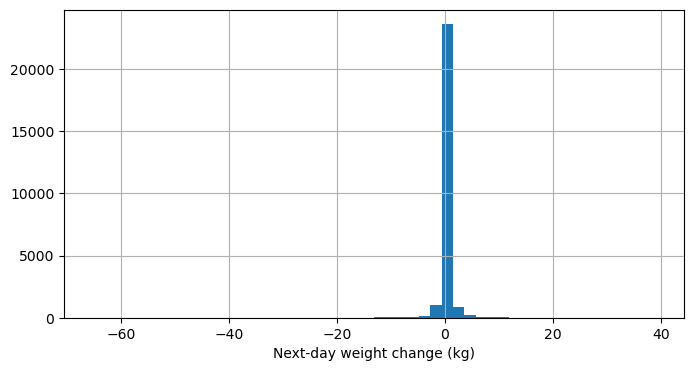

In [ ]:
model_df["target_next_day_weight_change_kg"].hist(
    bins=50,
    figsize=(8,4)
)

plt.xlabel("Next-day weight change (kg)")
plt.show()

In [ ]:
model_df[
    model_df["target_next_day_weight_change_kg"].abs() > 10
][[
    "end_of_day_weight_kg",
    "previous_day_weight_kg",
    "previous_day_weight_change_kg",
    "target_next_day_weight_change_kg"
]].head(50)

,end_of_day_weight_kg,previous_day_weight_kg,previous_day_weight_change_kg,target_next_day_weight_change_kg
286,67.599254,66.002512,1.596742,-12.122603
287,55.476652,67.599254,-12.122603,-10.286924
546,52.679399,52.814650,-0.135252,-10.807089
841,49.818756,49.817600,0.001156,-29.227707
842,20.591050,49.818756,-29.227707,-19.273329
931,19.714982,22.435081,-2.720099,-17.667834
942,18.102026,16.062926,2.039100,-12.900306
961,20.423551,21.989726,-1.566176,-19.067121
973,12.559806,12.361358,0.198447,-11.772367
1147,60.716249,60.441656,0.274594,-10.845537


In [ ]:
(model_df["target_next_day_weight_change_kg"].abs() > 10).sum()

np.int64(178)

In [ ]:
hive_df = con.execute("""
SELECT
    hive_id,
    measurement_date,
    end_of_day_weight_kg
FROM honey_model
WHERE hive_id = 75
ORDER BY measurement_date
""").df()

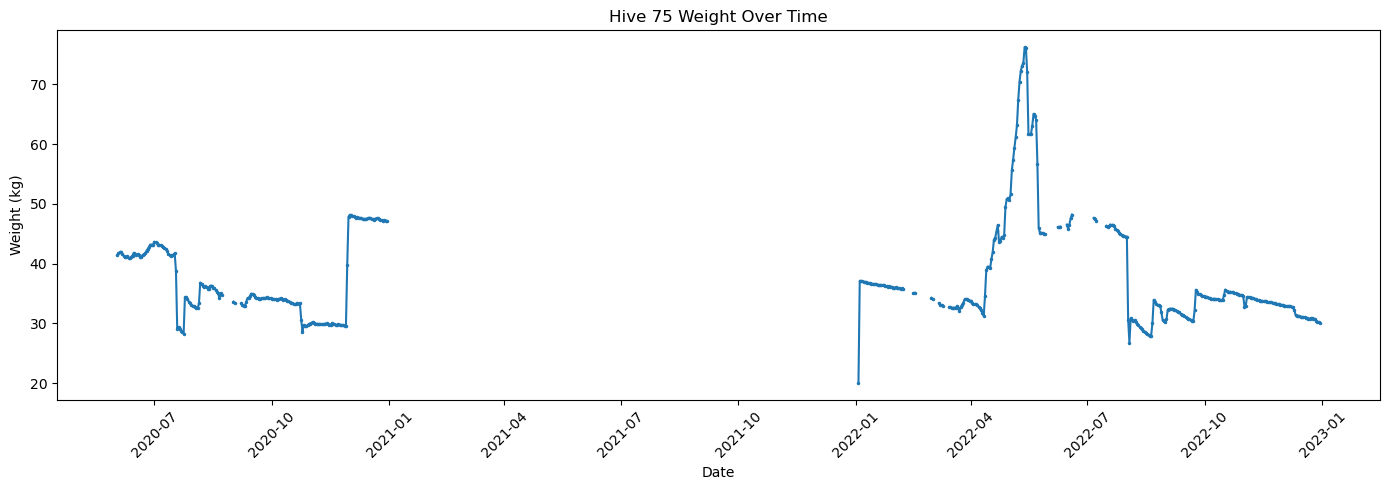

In [ ]:
hive_df = hive_df.sort_values("measurement_date").copy()

hive_df["days_since_previous"] = (
    hive_df["measurement_date"]
    .diff()
    .dt.days
)

# Break the plotted line across missing periods
hive_df["weight_for_plot"] = hive_df["end_of_day_weight_kg"]

hive_df.loc[
    hive_df["days_since_previous"] > 1,
    "weight_for_plot"
] = float("nan")

plt.figure(figsize=(14, 5))

plt.plot(
    hive_df["measurement_date"],
    hive_df["weight_for_plot"],
    marker=".",
    markersize=3
)

plt.title("Hive 75 Weight Over Time")
plt.xlabel("Date")
plt.ylabel("Weight (kg)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

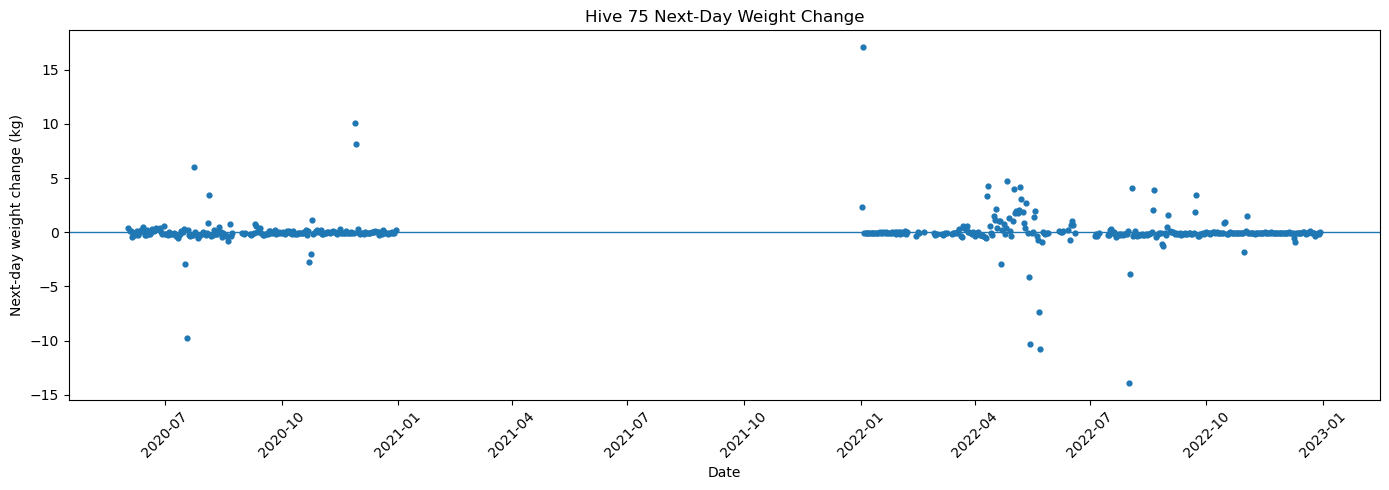

In [ ]:
hive_change_df = con.execute("""
SELECT
    measurement_date,
    end_of_day_weight_kg,
    target_next_day_weight_change_kg,
    large_next_day_change_flag
FROM honey_model
WHERE hive_id = 75
ORDER BY measurement_date;
""").df()

plt.figure(figsize=(14, 5))

plt.axhline(0, linewidth=1)

plt.scatter(
    hive_change_df["measurement_date"],
    hive_change_df["target_next_day_weight_change_kg"],
    s=12
)

plt.title("Hive 75 Next-Day Weight Change")
plt.xlabel("Date")
plt.ylabel("Next-day weight change (kg)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
hive_change_summary = con.execute("""
SELECT
    hive_id,
    COUNT(*) AS observation_count,
    AVG(target_next_day_weight_change_kg) AS mean_change,
    STDDEV(target_next_day_weight_change_kg) AS standard_deviation,
    MIN(target_next_day_weight_change_kg) AS minimum_change,
    MAX(target_next_day_weight_change_kg) AS maximum_change,
    MAX(ABS(target_next_day_weight_change_kg)) AS largest_absolute_change
FROM honey_model
GROUP BY hive_id
ORDER BY largest_absolute_change DESC
LIMIT 20;
""").df()

hive_change_summary

,hive_id,observation_count,mean_change,standard_deviation,minimum_change,maximum_change,largest_absolute_change
0,62,805,0.009579,3.563343,-65.322940,37.410926,65.322940
1,58,496,0.130658,1.897075,-4.659743,39.098176,39.098176
2,102,65,-0.757269,4.966520,-38.832701,1.420533,38.832701
3,112,492,0.067279,4.667613,-38.376500,25.362429,38.376500
4,109,897,0.068827,2.095103,-18.713476,36.047336,36.047336
5,72,324,0.042746,2.690553,-35.423970,18.425095,35.423970
6,84,255,0.108355,2.715047,-10.894487,35.118909,35.118909
7,134,463,-0.114081,2.135378,-31.529096,4.894664,31.529096
8,97,836,0.033757,1.704077,-30.000355,20.924770,30.000355
9,57,335,-0.036688,2.929060,-29.227707,6.850218,29.227707


In [ ]:
con.execute("""
SELECT
    measurement_date,
    COUNT(*) AS large_events
FROM honey_model
WHERE ABS(target_next_day_weight_change_kg) > 20
GROUP BY measurement_date
ORDER BY large_events DESC;
""").df()

,measurement_date,large_events
0,2020-05-07,3
1,2021-07-23,3
2,2022-08-05,2
3,2021-07-19,2
4,2019-10-12,1
5,2022-05-27,1
6,2020-05-09,1
7,2020-05-12,1
8,2020-05-13,1
9,2020-05-16,1


>
> **Investigation #1**

> Which hives were involved?

In [ ]:
con.execute("""
SELECT
    hive_id,
    measurement_date,
    previous_day_weight_kg,
    end_of_day_weight_kg,
    target_next_day_weight_change_kg
FROM honey_model
WHERE measurement_date = DATE '2020-05-07'
ORDER BY ABS(target_next_day_weight_change_kg) DESC;
""").df()

,hive_id,measurement_date,previous_day_weight_kg,end_of_day_weight_kg,target_next_day_weight_change_kg
0,102,2020-05-07,50.416046,49.019760,-38.832701
1,84,2020-05-07,0.242183,12.985323,35.118909
2,93,2020-05-07,0.007962,0.008424,22.016576
3,112,2020-05-07,76.063071,74.194942,-8.566850
4,0,2020-05-07,51.605719,54.780249,3.109340
5,47,2020-05-07,7.514951,9.362954,2.578662
6,57,2020-05-07,7.807022,8.340649,2.495728
7,67,2020-05-07,43.368023,45.578443,2.369071
8,128,2020-05-07,40.131409,40.159108,1.732735
9,3,2020-05-07,40.883049,42.220950,1.683056


>
> **Investigation #2**

> Look one week before and after

In [ ]:
con.execute("""
SELECT
    hive_id,
    measurement_date,
    previous_day_weight_kg,
    end_of_day_weight_kg,
    target_next_day_weight_change_kg
FROM honey_model
WHERE hive_id = 62

ORDER BY ABS(target_next_day_weight_change_kg) DESC;
""").df()

,hive_id,measurement_date,previous_day_weight_kg,end_of_day_weight_kg,target_next_day_weight_change_kg
0,62,2020-04-27,62.458326,99.869251,-65.322940
1,62,2020-04-26,41.127949,62.458326,37.410926
2,62,2022-05-26,111.726537,109.780383,-30.839355
3,62,2020-02-09,51.232957,64.754896,-24.636735
4,62,2020-04-18,50.614501,50.858445,-18.019794
...,...,...,...,...,...
800,62,2019-11-18,38.009011,38.120200,0.001691
801,62,2019-12-27,36.120334,35.929735,-0.001647
802,62,2020-03-29,46.831620,49.644490,-0.001319
803,62,2022-07-27,50.636457,50.341789,0.000602


>
> **Investigation #3**
>
>
> What percentage of observations are "large events?"

In [ ]:
(model_df["target_next_day_weight_change_kg"].abs() > 5).mean()

np.float64(0.016975014304787334)

>
> **Investigation #4**
>
>
> How Rare?

#### Hive 62 Observations

In [ ]:
hive_df = con.execute("""
SELECT
    hive_id,
    measurement_date,
    end_of_day_weight_kg
FROM honey_model
WHERE hive_id = 62
ORDER BY measurement_date
""").df()

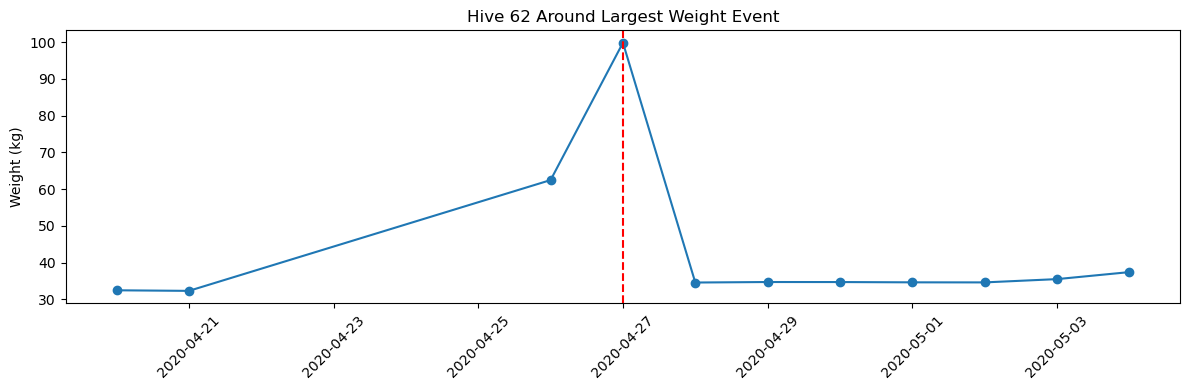

In [ ]:
event = pd.Timestamp("2020-04-27")

window = hive_df[
    (hive_df["measurement_date"] >= event - pd.Timedelta(days=7)) &
    (hive_df["measurement_date"] <= event + pd.Timedelta(days=7))
]

plt.figure(figsize=(12,4))
plt.plot(
    window["measurement_date"],
    window["end_of_day_weight_kg"],
    marker="o"
)

plt.axvline(event, color="red", linestyle="--")

plt.title("Hive 62 Around Largest Weight Event")
plt.ylabel("Weight (kg)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
(model_df["target_next_day_weight_change_kg"].abs() > 5).value_counts()

target_next_day_weight_change_kg
False    25770
True       445
Name: count, dtype: int64

> Investigation #5
>
> How many observations remain if we remove the obvious extreme events?

In [ ]:
filtered = model_df[
    model_df["target_next_day_weight_change_kg"].abs() <= 5
]

print(f"Original observations: {len(model_df):,}")
print(f"Filtered observations: {len(filtered):,}")
print(f"Removed: {len(model_df)-len(filtered):,}")

Original observations: 26,215
Filtered observations: 25,770
Removed: 445


### 9.10 Compare Routine and Extreme Weight Changes

In [ ]:
routine_df = model_df[
    model_df[target_column].abs() <= 5
].copy()

print(f"Original observations: {len(model_df):,}")
print(f"Routine-change observations: {len(routine_df):,}")
print(f"Extreme observations removed: {len(model_df) - len(routine_df):,}")

Original observations: 26,215
Routine-change observations: 25,770
Extreme observations removed: 445


In [ ]:
(
    X_train_routine,
    X_test_routine,
    y_train_routine,
    y_test_routine,
    cutoff_routine
) = chronological_split(
    routine_df,
    feature_columns,
    target_column
)

In [ ]:
(model_df["target_next_day_weight_change_kg"].abs() > 5).mean()

np.float64(0.016975014304787334)

In [ ]:
print(f"Training observations: {len(X_train_routine):,}")
print(f"Testing observations: {len(X_test_routine):,}")
print(f"Testing begins: {cutoff_routine}")

Training observations: 19,930
Testing observations: 5,840
Testing begins: 2022-03-31T00:00:00.000000


In [ ]:
rf_routine = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_routine.fit(X_train_routine, y_train_routine)

routine_predictions = rf_routine.predict(X_test_routine)

print("Routine Random Forest trained successfully.")

Routine Random Forest trained successfully.


>
>Hypothesis: The baseline Random Forest performs poorly because rare intervention-like events are fundamentally unpredictable from the available predictors.
>

In [ ]:
baseline_rmse = root_mean_squared_error(y_test_hist, history_predictions)
baseline_mae = mean_absolute_error(y_test_hist, history_predictions)
baseline_r2 = r2_score(y_test_hist, history_predictions)

In [ ]:
routine_predictions = rf_routine.predict(X_test_routine)

routine_rmse = root_mean_squared_error(
    y_test_routine,
    routine_predictions
)

routine_mae = mean_absolute_error(
    y_test_routine,
    routine_predictions
)

routine_r2 = r2_score(
    y_test_routine,
    routine_predictions
)

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Routine Only"
    ],
    "RMSE": [
        baseline_rmse,
        routine_rmse
    ],
    "MAE": [
        baseline_mae,
        routine_mae
    ],
    "R²": [
        baseline_r2,
        routine_r2
    ]
})


In [ ]:
comparison = comparison.round(3)

comparison

,Model,RMSE,MAE,R²
0,Baseline,3.090,0.861,-1.23
1,Routine Only,0.774,0.385,0.12


### 9.11 Conclusions

Initial modeling demonstrated poor predictive performance (RMSE = 3.09 kg, R² = -1.23). Exploratory analysis revealed that approximately 1.7% of observations represented unusually large next-day weight changes (>5 kg). These events clustered on specific dates and hives, suggesting they may reflect beekeeper interventions or other atypical conditions rather than routine colony dynamics. A second model trained exclusively on routine observations substantially improved predictive accuracy (RMSE = 0.77 kg, R² = 0.12), indicating that routine hive weight changes are considerably more predictable than extreme events.

>#### Key Finding
>
>Removing approximately 1.7% of observations representing unusually large (>5 kg) next-day weight changes reduced RMSE from 3.09 kg to 0.77 kg and improved R² from -1.23 to 0.12. These findings suggest that routine colony weight dynamics are substantially more predictable than rare intervention-driven or otherwise atypical events.
>